In [5]:

from google.colab import files
import pandas as pd
import io

print(" Please upload your preprocessed wildfire dataset (.csv)")
uploaded = files.upload()

if not uploaded:
    raise ValueError("❌ No file uploaded. Please rerun and upload a CSV file.")

CSV_PATH = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[CSV_PATH]))

print(f" Uploaded File: {CSV_PATH}")
print(" Dataset Loaded — Shape:", df.shape)

# --- User Settings ---
TARGET_COL = "area"   # target variable for regression
TEST_SIZE = 0.2
RANDOM_STATE = 42
CATEGORICAL_COLS = []    # e.g., ['region','month']
RUN_TUNING = True        # set False to skip tuning

df.head()


 Please upload your preprocessed wildfire dataset (.csv)


Saving final_processed_pipeline.csv to final_processed_pipeline.csv
 Uploaded File: final_processed_pipeline.csv
 Dataset Loaded — Shape: (220, 6)


,DC,temp,DMC,RH,ISI,area
0,0.607908,0.354497,0.000000,0.327273,0.159664,0.0
1,0.653316,0.174603,0.048368,0.327273,0.159664,0.0
2,0.145918,0.576720,0.290793,0.254545,0.831933,0.0
3,0.165306,0.677249,0.311772,0.218182,0.310924,0.0
4,0.667857,0.095238,0.548368,0.872727,0.184874,0.0


 Dataset loaded successfully: (220, 6)


,DC,temp,DMC,RH,ISI,area
0,0.607908,0.354497,0.000000,0.327273,0.159664,0.0
1,0.653316,0.174603,0.048368,0.327273,0.159664,0.0
2,0.145918,0.576720,0.290793,0.254545,0.831933,0.0
3,0.165306,0.677249,0.311772,0.218182,0.310924,0.0
4,0.667857,0.095238,0.548368,0.872727,0.184874,0.0



 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DC      220 non-null    float64
 1   temp    220 non-null    float64
 2   DMC     220 non-null    float64
 3   RH      220 non-null    float64
 4   ISI     220 non-null    float64
 5   area    220 non-null    float64
dtypes: float64(6)
memory usage: 10.4 KB
None


,count,mean,std,min,25%,50%,75%,max
DC,220.0,0.606320,0.223467,0.0,0.493367,0.652296,0.759694,1.00
temp,220.0,0.490308,0.195423,0.0,0.353175,0.481481,0.619048,1.00
DMC,220.0,0.480160,0.203305,0.0,0.358392,0.460373,0.598048,1.00
RH,220.0,0.473471,0.215364,0.0,0.327273,0.454545,0.600000,1.00
ISI,220.0,0.376547,0.226324,0.0,0.193277,0.336134,0.487395,1.00
area,220.0,1.220864,1.920072,0.0,0.000000,0.000000,1.787500,7.21


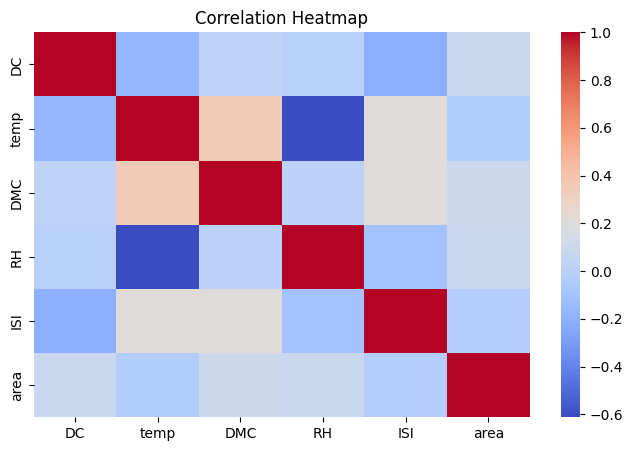


 Train shape: (176, 5) | Test shape: (44, 5)

 Scaling completed successfully.


In [7]:
# === 🔧 Minimal Preparation After Upload (for SVR) ===
import seaborn as sns, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

#  1. Verify dataset
print(" Dataset loaded successfully:", df.shape)
display(df.head())

# 1️ Quick EDA check
print("\n Dataset Info:")
print(df.info())
display(df.describe().T)

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

#  2. Feature / Target split
TARGET_COL = "area"   # change if target column differs
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# 3. Train–Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f"\n Train shape: {X_train.shape} | Test shape: {X_test.shape}")

#  4. Feature scaling (essential for SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("\n Scaling completed successfully.")

#  5. Common evaluation function
def evaluate_model(y_true, y_pred, name="Model"):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"\n{name} Results:")
    print(f"R²   = {r2:.4f}")
    print(f"MAE  = {mae:.4f}")
    print(f"RMSE = {rmse:.4f}")
    return r2, mae, rmse

## 1. Imports

Support Vector Regressor (SVR)

In [8]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np, seaborn as sns, matplotlib.pyplot as plt

In [9]:
# Step 1 – Create model
svr = SVR(kernel="rbf")

In [10]:
# Step 2 - Train model
svr.fit(X_train_scaled, y_train)

SVR()

In [11]:
# Step 3 – Predict
y_pred_svr = svr.predict(X_test_scaled)

In [12]:
# Step 4 – Evaluate metrics
r2_svr = r2_score(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))

print(" Support Vector Regressor (Base Model):")
print(f"R² = {r2_svr:.4f}, MAE = {mae_svr:.4f}, RMSE = {rmse_svr:.4f}")


 Support Vector Regressor (Base Model):
R² = -0.1966, MAE = 1.4026, RMSE = 2.2864


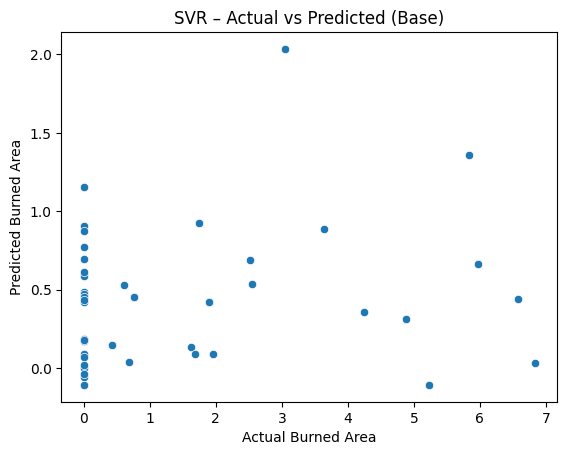

In [13]:
# Step 5 - Visualize Actual vs Predicted
sns.scatterplot(x=y_test, y=y_pred_svr)
plt.xlabel("Actual Burned Area")
plt.ylabel("Predicted Burned Area")
plt.title("SVR – Actual vs Predicted (Base)")
plt.show()

Hyperparameter Tuning (Experiment 1 & 2)

In [14]:
from sklearn.model_selection import GridSearchCV

# --- Experiment 1 ---
param_grid_svr1 = {
    "kernel": ["linear", "rbf"],
    "C": [0.1, 1, 10],
    "gamma": ["scale", "auto"]
}
grid_svr1 = GridSearchCV(SVR(), param_grid_svr1, cv=5, scoring="r2", n_jobs=-1)
grid_svr1.fit(X_train_scaled, y_train)
print(" Best Params (Exp 1):", grid_svr1.best_params_)
print("Best CV R²:", grid_svr1.best_score_)

# --- Experiment 2 (finer tuning around the best kernel) ---
param_grid_svr2 = {
    "kernel": ["rbf"],
    "C": [0.5, 1, 2, 5, 10],
    "gamma": [0.001, 0.01, 0.1, 1, "scale"]
}
grid_svr2 = GridSearchCV(SVR(), param_grid_svr2, cv=10, scoring="r2", n_jobs=-1)
grid_svr2.fit(X_train_scaled, y_train)
print(" Best Params (Exp 2):", grid_svr2.best_params_)
print("Best CV R²:", grid_svr2.best_score_)


 Best Params (Exp 1): {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV R²: -0.1939314900481381
 Best Params (Exp 2): {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Best CV R²: -0.21516698689703578


Evaluate Tuned Models and Compare

,Model,R²,MAE,RMSE
0,Base SVR,-0.196552,1.402561,2.286430
1,Tuned Grid 1,-0.196552,1.402561,2.286430
2,Tuned Grid 2,-0.136225,1.437533,2.228048


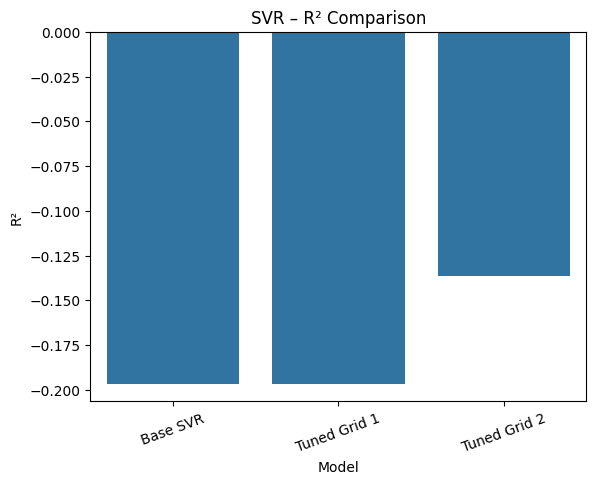

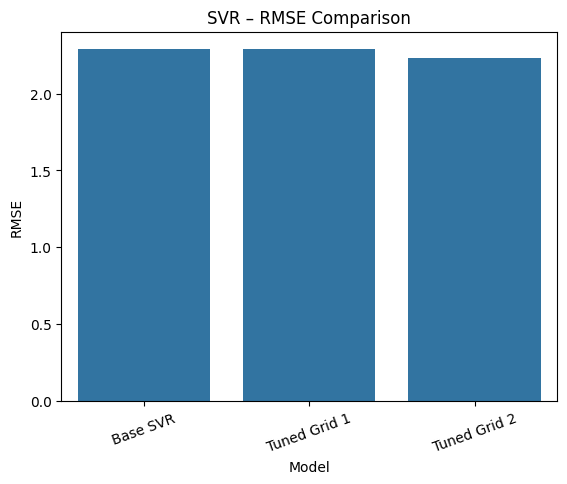

In [15]:
from math import sqrt
import pandas as pd

# Grid 1
best_svr1 = grid_svr1.best_estimator_
pred1 = best_svr1.predict(X_test_scaled)
r2_1 = r2_score(y_test, pred1)
mae_1 = mean_absolute_error(y_test, pred1)
rmse_1 = sqrt(mean_squared_error(y_test, pred1))

# Grid 2
best_svr2 = grid_svr2.best_estimator_
pred2 = best_svr2.predict(X_test_scaled)
r2_2 = r2_score(y_test, pred2)
mae_2 = mean_absolute_error(y_test, pred2)
rmse_2 = sqrt(mean_squared_error(y_test, pred2))

# Combine all results
comparison = pd.DataFrame({
    "Model": ["Base SVR", "Tuned Grid 1", "Tuned Grid 2"],
    "R²": [r2_svr, r2_1, r2_2],
    "MAE": [mae_svr, mae_1, mae_2],
    "RMSE": [rmse_svr, rmse_1, rmse_2]
})
display(comparison)

# Visualization
sns.barplot(x="Model", y="R²", data=comparison)
plt.title("SVR – R² Comparison")
plt.xticks(rotation=20)
plt.show()

sns.barplot(x="Model", y="RMSE", data=comparison)
plt.title("SVR – RMSE Comparison")
plt.xticks(rotation=20)
plt.show()
